# Loading and Summarizing Data
## FloodNet NYC Tutorial
Author: Mark Bauer

# Summary
We'll demonstrate how to load FloodNet data, as well as inspect and summarize it.

# Import Libraries

In [1]:
# libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import polars as pl
import duckdb
import seaborn as sns

In [2]:
# print versions of packages for reproducibility
libraries = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "geopandas": gpd.__version__,
    "matplotlib": matplotlib.__version__,
    "polars": pl.__version__,
    "duckdb": duckdb.__version__,
    "seaborn": sns.__version__,
}

for name, version in libraries.items():
    print(f"{name:10s} {version}")

numpy      2.4.2
pandas     3.0.1
geopandas  1.1.2
matplotlib 3.10.8
polars     1.38.1
duckdb     1.4.4
seaborn    0.13.2


In [3]:
# configure table formatting
pl.Config(tbl_cols=50, tbl_rows=100)

# Load and Inspect Datasets

In [4]:
# list files in data directory
%ls data

Flood Events_Data Dictionary.xlsx
Floodnet_Open_Data_-_Data_Description_03.05.2026.pdf
boroughs.parquet
flood-events.csv
sensor-metadata.csv


In [5]:
# read in flood sensor deployments as dataframe
metadata_path = "data/sensor-metadata.csv"
metadata_df = pl.read_csv(metadata_path, try_parse_dates=True)

# inspect the shape of the data
n_rows, n_columns = metadata_df.shape
print("Metadata:")
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_columns}")

# read in flood events as dataframe
events_path = "data/flood-events.csv"
events_df = pl.read_csv(
    events_path,
    # some columns have sparce data, need to expand the row count
    infer_schema_length=100000,
    try_parse_dates=True
)

# inspect the shape of the data
n_rows, n_columns = events_df.shape
print("\nFlood Events:")
print(f"Number of rows: {n_rows:,}")
print(f"Number of columns: {n_columns}")

Metadata:
Number of rows: 380
Number of columns: 16

Flood Events:
Number of rows: 1,887
Number of columns: 13


# Sensor Metadata Dataset

In [6]:
# preview dataframe
metadata_df.head()

sensor_name,sensor_id,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str
"""BK - Georgia Ave/ Livonia Ave""","""BK-livonia-ave-georgia-ave-2tz…",2026-03-06 00:00:00,"""No""",null,"""Georgia Avenue""","""Brooklyn""",11207,305,"""BK05""",3112600,"""BK0503""",40.664423,-73.895839,7.95,"""POINT (-73.895839 40.664423)"""
"""Q - Roosevelt Ave/Prince St""","""Q-roosevelt-ave-prince-st-2t7s…",2026-02-19 00:00:00,"""No""",null,"""Roosevelt Avenue""","""Queens""",11354,407,"""QN07""",4087100,"""QN0707""",40.758898,-73.832241,6.5,"""POINT (-73.832241 40.758898)"""
"""BK - Lott Ave/Thatford Ave""","""BK-lott-ave-thatford-ave-2tzql…",2026-03-06 00:00:00,"""No""",null,"""Lott Avenue""","""Brooklyn""",11212,316,"""BK16""",3092000,"""BK1602""",40.658076,-73.90676,8.19,"""POINT (-73.90676 40.658076)"""
"""BK - Linden Blvd/Vermont St""","""BK-vermont-st-linden-blvd-2tzq…",2026-03-06 00:00:00,"""No""",null,"""Linden Boulevard""","""Brooklyn""",11207,305,"""BK05""",3110400,"""BK0503""",40.659197,-73.888368,11.42,"""POINT (-73.888368 40.659197)"""
"""BK - Halsey St/Saratoga Ave""","""BK-halsey-st-saratoga-ave-2tzm…",2026-03-06 00:00:00,"""No""",null,"""Halsey Street""","""Brooklyn""",11233,303,"""BK03""",3037700,"""BK0302""",40.685532,-73.917807,6.97,"""POINT (-73.917807 40.685532)"""


In [7]:
# check if IDs are unique
(
    metadata_df.filter(pl.col("date_removed").is_null())
        .select([
            pl.col("sensor_id").is_duplicated().sum().alias("sensor_id_unique"),
            pl.col("sensor_name").is_duplicated().sum().alias("sensor_name_unique")
        ])
)

sensor_id_unique,sensor_name_unique
u32,u32
0,0


In [8]:
# number of missing values per column
metadata_df.null_count()

sensor_name,sensor_id,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,340,0,0,0,0,0,0,0,0,0,0,0


In [9]:
# dense preview of dataframe
metadata_df.glimpse(
    max_items_per_column=3,
    return_type='frame'
)

column,dtype,values
str,str,list[str]
"""sensor_name""","""str""","[""'BK - Georgia Ave/ Livonia Ave'"", ""'Q - Roosevelt Ave/Prince St'"", ""'BK - Lott Ave/Thatford Ave'""]"
"""sensor_id""","""str""","[""'BK-livonia-ave-georgia-ave-2tzr8o'"", ""'Q-roosevelt-ave-prince-st-2t7spo'"", ""'BK-lott-ave-thatford-ave-2tzqlc'""]"
"""date_installed""","""datetime[μs]""","[""2026-03-06 00:00:00"", ""2026-02-19 00:00:00"", ""2026-03-06 00:00:00""]"
"""tidally_influenced""","""str""","[""'No'"", ""'No'"", ""'No'""]"
"""date_removed""","""datetime[μs]""","[null, null, null]"
"""street_name""","""str""","[""'Georgia Avenue'"", ""'Roosevelt Avenue'"", ""'Lott Avenue'""]"
"""borough""","""str""","[""'Brooklyn'"", ""'Queens'"", ""'Brooklyn'""]"
"""zipcode""","""i64""","[""11207"", ""11354"", ""11212""]"
"""community_board""","""i64""","[""305"", ""407"", ""316""]"


In [10]:
# summary statistics
metadata_df.describe()

statistic,sensor_name,sensor_id,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,str,str,str,str,str,str,f64,f64,str,f64,str,f64,f64,f64,str
"""count""","""380""","""380""","""380""","""380""","""40""","""380""","""380""",380.0,380.0,"""380""",380.0,"""380""",380.0,380.0,380.0,"""380"""
"""null_count""","""0""","""0""","""0""","""0""","""340""","""0""","""0""",0.0,0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,"""0"""
"""mean""",null,null,"""2024-07-02 05:14:31.578947""",null,"""2024-08-26 21:00:00""",null,null,10934.665789,315.131579,null,3.1140e6,null,40.709983,-73.912776,11.2235,null
"""std""",null,null,null,null,null,null,null,529.330499,114.802658,null,1.1610e6,null,0.085743,0.097794,8.307998,null
"""min""","""BK - Farragut Rd/ Rockaway Pk…","""BK-10th-ave-76th-st-1umos0""","""2020-10-05 00:00:00""","""No""","""2021-12-10 00:00:00""","""100th Street""","""Bronx""",10002.0,101.0,"""BK01""",1.0008e6,"""BK0101""",40.531504,-74.206958,0.0,"""POINT (-73.729558 40.65572)"""
"""25%""",null,null,"""2024-01-12 00:00:00""",null,"""2023-10-12 00:00:00""",null,null,10459.0,210.0,null,2.0356e6,null,40.650531,-73.970166,7.44,null
"""50%""",null,null,"""2024-08-08 00:00:00""",null,"""2024-12-13 00:00:00""",null,null,11213.0,313.0,null,3.059e6,null,40.698449,-73.917187,9.45,null
"""75%""",null,null,"""2025-03-27 00:00:00""",null,"""2025-08-21 00:00:00""",null,null,11368.0,410.0,null,4.0473e6,null,40.763964,-73.839728,11.89,null
"""max""","""SI - Willow Rd E/Nina Ave""","""SI-willow-rd-e-nina-ave-0xx2c0""","""2026-03-06 00:00:00""","""Yes""","""2025-11-25 00:00:00""","""Wythe Avenue""","""Staten Island""",11693.0,503.0,"""SI03""",5.029105e6,"""SI0304""",40.90418,-73.729558,64.96,"""POINT (-74.206958 40.531504)"""


# NYC Borough Boundaries

In [11]:
# read in NYC Boroughs geometries from NYC Open Data
path = "data/boroughs.parquet"
boro_gdf = gpd.read_parquet(path)

boro_gdf.head()

,borocode,boroname,shape_area,shape_leng,geometry
0,5,Staten Island,1623618358.46,325912.288988,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,1,Manhattan,636631650.451,359537.866079,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
2,2,Bronx,1187199300.36,463147.071867,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."
3,3,Brooklyn,1934462607.43,726953.044632,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."
4,4,Queens,3041419178.99,887905.076018,"MULTIPOLYGON (((-73.82645 40.59053, -73.82642 ..."


In [12]:
# confirm CRS
boro_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [13]:
# generate geometry from x, y points
geometry = gpd.points_from_xy(
    metadata_df['longitude'],
    metadata_df['latitude']
)

# these coordinates are stored in 4326
crs = 4326

# create geodataframe
metadata_gdf = gpd.GeoDataFrame(
    metadata_df.to_pandas(),
    geometry=geometry,
    crs=crs
)

# sanity checks
print(f'shape of data: {metadata_gdf.shape}')
print(metadata_gdf.crs)

# preview data
metadata_gdf['geometry'].head()

shape of data: (380, 17)
EPSG:4326


0    POINT (-73.89584 40.66442)
1     POINT (-73.83224 40.7589)
2    POINT (-73.90676 40.65808)
3     POINT (-73.88837 40.6592)
4    POINT (-73.91781 40.68553)
Name: geometry, dtype: geometry

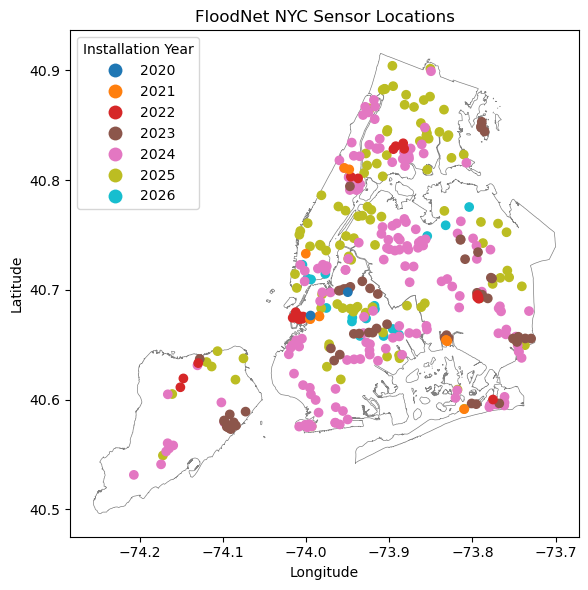

In [14]:
# create figure
fig, ax = plt.subplots(figsize=(6, 6))

# sort on date ascending, we want to see old sensors on top
plot_gdf = metadata_gdf.sort_values(by='date_installed', ascending=False)

# sensors plot
plot_gdf.plot(
    column=plot_gdf['date_installed'].dt.year.astype(str),
    categorical=True,
    ax=ax,
    legend=True,
    legend_kwds={"title": "Installation Year"},
)

# borough plot
boro_gdf.plot(
    ax=ax,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# figure labels
plt.title("FloodNet NYC Sensor Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# tight layout
plt.tight_layout()

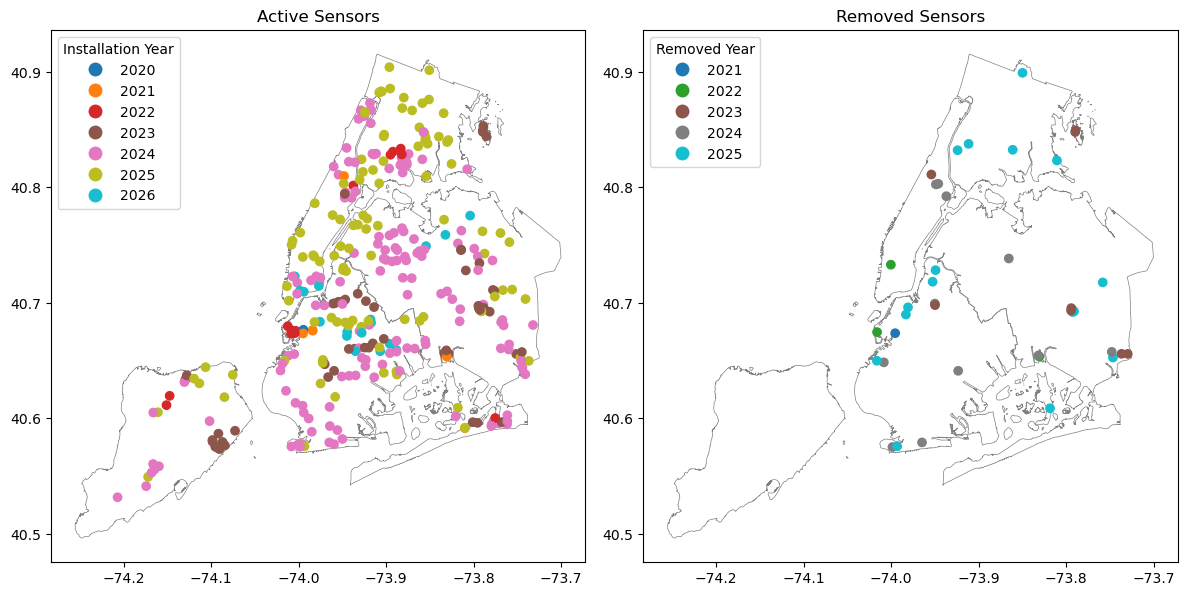

In [15]:
# create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 12))

# active sensors
sensors_active_df = (
    metadata_gdf.loc[metadata_gdf['date_removed'].isna()]
)

sensors_active_df.plot(
    ax=ax1,
    column=sensors_active_df['date_installed'].dt.year.astype(str),
    categorical=True,
    legend=True,
    legend_kwds={"title": "Installation Year"}

)

# sensors removed
sensors_removed_df = (
    metadata_gdf.loc[~metadata_gdf['date_removed'].isna()]
)
 
sensors_removed_df.plot(
    ax=ax2,
    column=sensors_removed_df['date_removed'].dt.year.astype(str),
    categorical=True,
    legend=True,
    legend_kwds={"title": "Removed Year"}
)

# borough plot
boro_gdf.plot(
    ax=ax1,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# borough plot
boro_gdf.plot(
    ax=ax2,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# figure labels
ax1.set_title("Active Sensors")
ax2.set_title("Removed Sensors")

plt.tight_layout()

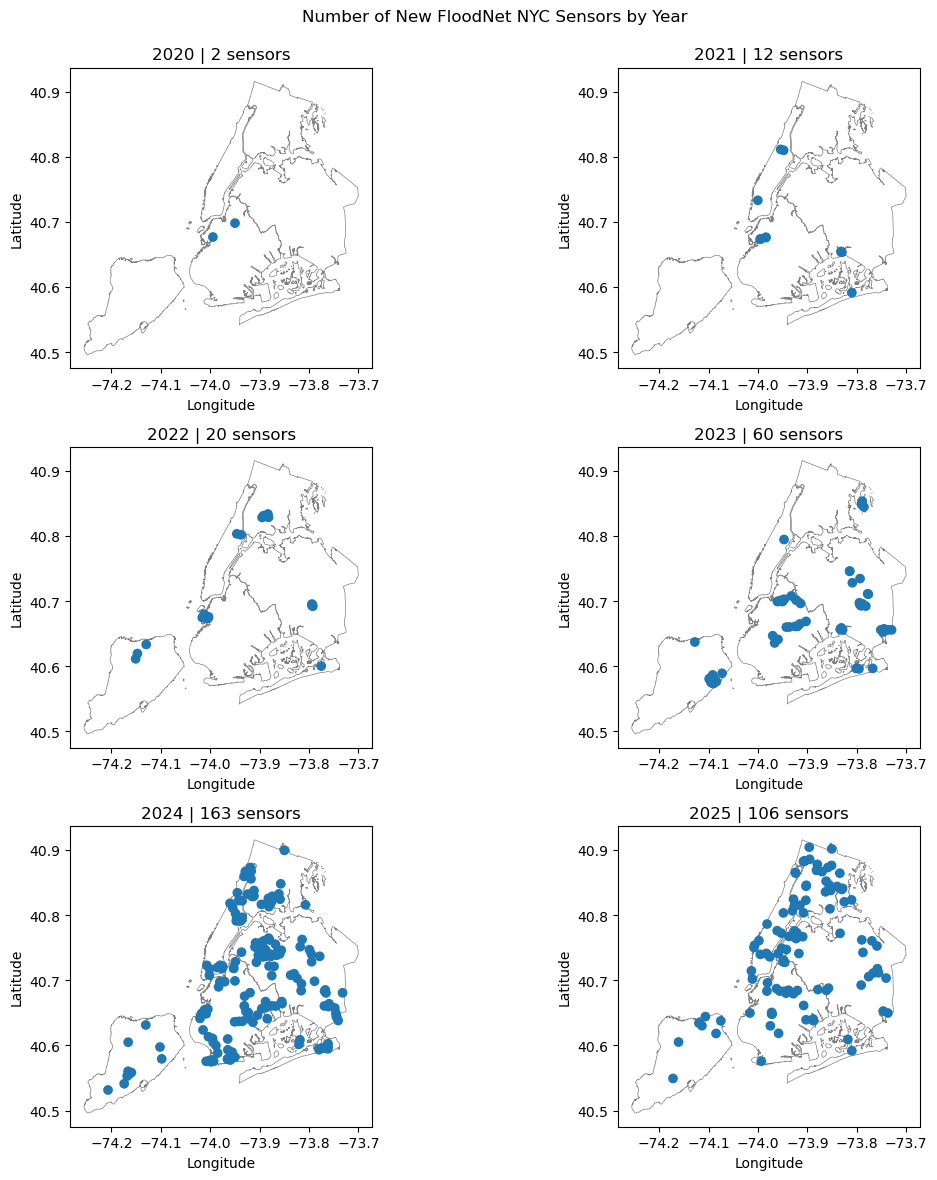

In [16]:
# create figure
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

# plot only active sensors
years = metadata_gdf['date_installed'].dt.year.sort_values().unique()

for year, ax in zip(years, axs.flat):

    # sensors plot
    plot_df = metadata_gdf.loc[
        metadata_gdf['date_installed'].dt.year == int(year)
    ]
    plot_df.plot(
        column=plot_df['date_installed'].dt.year.astype(str),
        categorical=True,
        ax=ax,
    )

    # borough plot
    boro_gdf.plot(
        ax=ax,
        facecolor="None", linewidth=.5, edgecolor="gray",
        zorder=0
    )

    # figure labels
    ax.set_title(f"{year} | {plot_df.shape[0]} sensors")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
fig.suptitle("Number of New FloodNet NYC Sensors by Year\n")    
fig.tight_layout()    

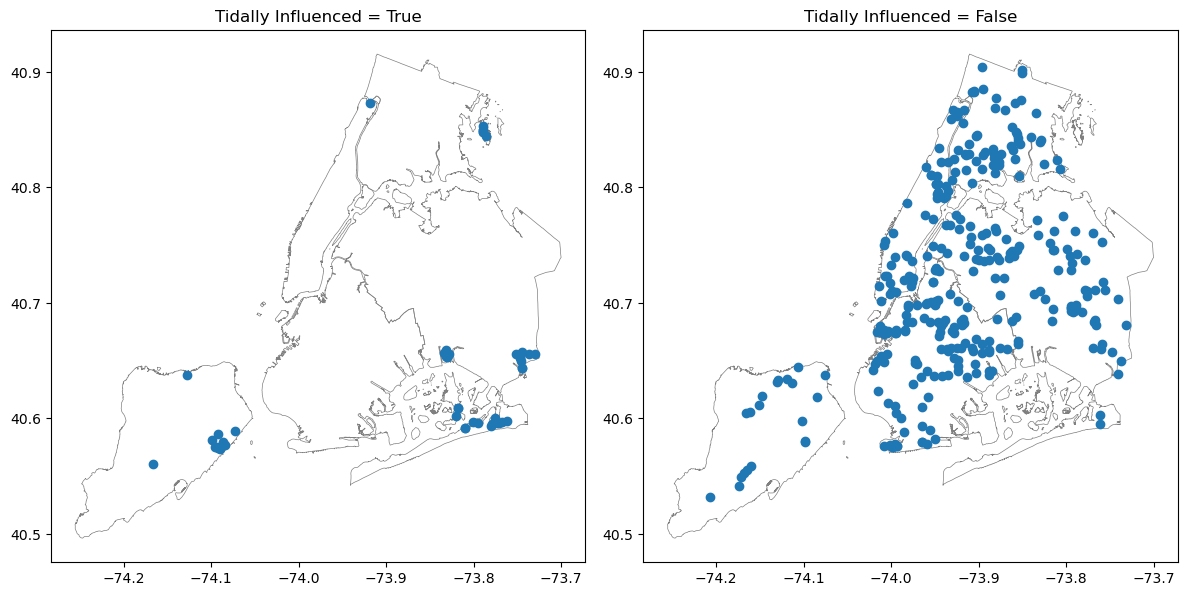

In [17]:
# create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 12))

# sensors plot
(metadata_gdf.loc[metadata_gdf['tidally_influenced'] == "Yes"]
 .plot(ax=ax1)
)

# borough plot
boro_gdf.plot(
    ax=ax1,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# sensors plot
(metadata_gdf.loc[metadata_gdf['tidally_influenced'] == "No"]
 .plot(ax=ax2)
)

# borough plot
boro_gdf.plot(
    ax=ax2,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# figure labels
ax1.set_title("Tidally Influenced = True")
ax2.set_title("Tidally Influenced = False")

plt.tight_layout()

In [18]:
metadata_df.select(pl.col('lowest_point_height_delta_inches')).describe()

statistic,lowest_point_height_delta_inches
str,f64
"""count""",380.0
"""null_count""",0.0
"""mean""",11.2235
"""std""",8.307998
"""min""",0.0
"""25%""",7.44
"""50%""",9.45
"""75%""",11.89
"""max""",64.96


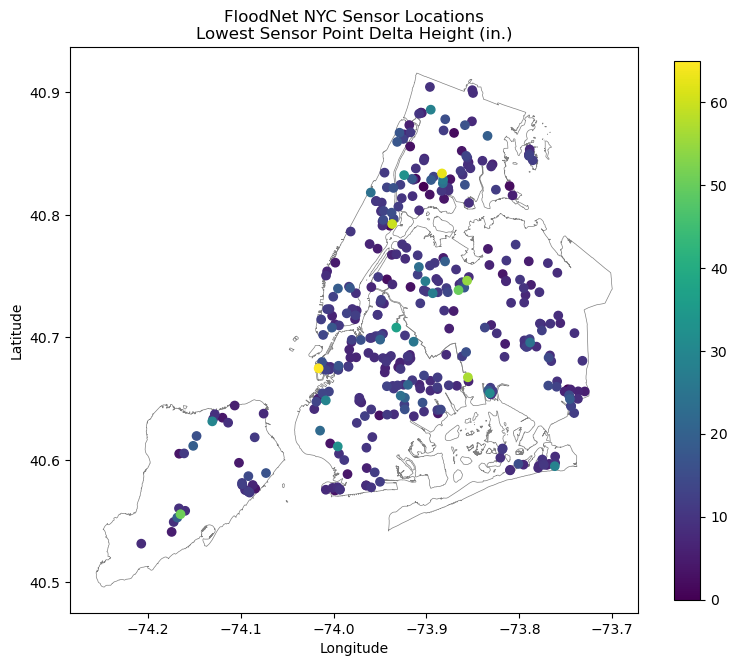

In [19]:
# create figure
fig, ax = plt.subplots(figsize=(8, 8))

# highest values on top of map
plot_gdf = metadata_gdf.sort_values(by='lowest_point_height_delta_inches')

# sensors plot
plot_gdf.plot(
    column="lowest_point_height_delta_inches",
    ax=ax,
    legend=True,
    legend_kwds={
        "shrink": 0.70, # Shrinks the colorbar to 50% of the axis height
    },
)

# borough plot
boro_gdf.plot(
    ax=ax,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# figure aesthetics
plt.title("FloodNet NYC Sensor Locations\nLowest Sensor Point Delta Height (in.)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# tight layout
plt.tight_layout()

# Flood Events Dataset

In [20]:
# preview the first few rows
events_df.head()

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,str
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…"
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…"
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…"
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…"
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…"


In [21]:
# preview count of events
events_sensors = events_df.get_column("sensor_id").len()
print(f"Number of flood events from all sensors: {events_sensors:,}")

sensors_unique = events_df.get_column("sensor_id").n_unique()
print(f"Number of unique sensors with recorded flooding: {sensors_unique}")

Number of flood events from all sensors: 1,887
Number of unique sensors with recorded flooding: 168


In [22]:
# inspect column information and data types
events_df.glimpse(max_items_per_column=5, return_type='frame')

column,dtype,values
str,str,list[str]
"""sensor_name""","""str""","[""'Q - Beach 84 St'"", ""'BX - 1st St/Avenue A'"", … ""'Q - Davenport Ct 1'""]"
"""sensor_id""","""str""","[""'Q-beach-84-st-0me680'"", ""'BX-1st-st-avenue-a-1zby90'"", … ""'Q-davenport-ct-1-07zks0'""]"
"""flood_start_time""","""datetime[μs]""","[""2023-10-30 12:00:39"", ""2025-04-26 23:17:20"", … ""2024-01-10 00:39:25""]"
"""flood_end_time""","""datetime[μs]""","[""2023-10-30 16:38:19"", ""2025-04-27 11:55:34"", … ""2024-01-10 02:30:40""]"
"""max_depth_inches""","""f64""","[""17.72"", ""6.18"", … ""2.09""]"
"""onset_time_mins""","""f64""","[""133.86"", ""27.95"", … ""59.82""]"
"""drain_time_mins""","""f64""","[""143.81"", ""730.29"", … ""51.43""]"
"""duration_mins""","""f64""","[""277.66"", ""758.24"", … ""111.25""]"
"""duration_above_4_inches_mins""","""f64""","[""211.41"", ""132.81"", … ""0.0""]"


In [23]:
# convert date columns to datetime
events_df = events_df.with_columns(
    pl.col("flood_start_time")
        .dt.convert_time_zone(time_zone='America/New_York')
        .alias("flood_start_time_est"),
    pl.col("flood_end_time")
        .dt.convert_time_zone(time_zone='America/New_York')
        .alias("flood_end_time_est")
)

# preview new dtypes
events_df.head()

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_est,flood_end_time_est
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]"
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…",2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…",2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…",2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…",2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…",2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST


In [24]:
# number of missing values per column (sorted descending)
events_df.null_count()

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_est,flood_end_time_est
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [25]:
# summary statistics of numeric columns
events_df.describe()

statistic,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_est,flood_end_time_est
str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str
"""count""","""1887""","""1887""","""1887""","""1887""",1887.0,1887.0,1887.0,1887.0,1887.0,1887.0,1887.0,"""1887""","""1887""","""1887""","""1887"""
"""null_count""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0"""
"""mean""",null,null,"""2024-06-21 22:45:11.897721""","""2024-06-22 01:39:25.863804""",5.672173,65.591484,108.641569,174.232899,54.723715,8.77318,0.80753,null,null,"""2024-06-21 18:45:11.897721-04:…","""2024-06-21 21:39:25.863804-04:…"
"""std""",null,null,null,null,4.943472,82.997968,177.082204,221.591563,82.513816,38.750084,10.227863,null,null,null,null
"""min""","""BK - 16th Ave/80th St""","""BK-10th-ave-76th-st-1umos0""","""2020-11-16 01:41:17""","""2020-11-16 04:12:05""",0.47,1.0,3.0,5.0,0.0,0.0,0.0,"""[0.00, 0.00, 0.00, 0.00, 0.00,…","""[0, 1007, 1069, 2014, 3022, 36…","""2020-11-15 20:41:17-05:00""","""2020-11-15 23:12:05-05:00"""
"""25%""",null,null,"""2023-10-15 00:02:56""","""2023-10-15 04:33:47""",2.36,23.27,36.73,70.48,0.0,0.0,0.0,null,null,"""2023-10-14 20:02:56-04:00""","""2023-10-15 00:33:47-04:00"""
"""50%""",null,null,"""2024-07-28 20:55:37""","""2024-07-28 23:16:43""",4.21,47.39,62.07,133.76,8.23,0.0,0.0,null,null,"""2024-07-28 16:55:37-04:00""","""2024-07-28 19:16:43-04:00"""
"""75%""",null,null,"""2025-07-02 05:37:28""","""2025-07-02 07:43:16""",7.24,88.24,121.42,206.52,90.53,0.0,0.0,null,null,"""2025-07-02 01:37:28-04:00""","""2025-07-02 03:43:16-04:00"""
"""max""","""SI - Willow Rd E/Nina Ave""","""SI-willow-rd-e-nina-ave-0xx2c0""","""2026-01-07 15:14:27""","""2026-01-07 17:14:27""",40.87,1647.58,2782.15,3485.99,749.86,516.27,245.3,"""[3.43, 3.98, 4.57, 5.12, 5.47,…","""[63, 126, 189, 252, 315, 378, …","""2026-01-07 10:14:27-05:00""","""2026-01-07 12:14:27-05:00"""


## Join Sensor Metadata and Flood Events Datasets

In [26]:
# merge flood sensor events with sensor metadata
merged_df = events_df.join(
    metadata_df.drop("sensor_name"),
    on="sensor_id",
    how="left",  # keep all events, even if metadata is missing
)

# inspect the shape of the merged data
n_rows, n_columns = merged_df.shape
print(f"Number of rows of merged df: {n_rows:,}")
print(f"Number of columns: {n_columns}")

# events without matching metadata
missing_meta_count = merged_df["sensor_id"].null_count()
print(f"Events without matching sensor metadata: {missing_meta_count}\n")

# preview the first few rows
merged_df.head()

Number of rows of merged df: 1,887
Number of columns: 29
Events without matching sensor metadata: 0



sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_est,flood_end_time_est,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…",2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT,2021-12-10 00:00:00,"""Yes""",null,"""Beach 84th Street""","""Queens""",11693,414,"""QN14""",4094202,"""QN1402""",40.59136,-73.80996,8.27,"""POINT (-73.80996 40.59136)"""
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…",2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT,2024-07-18 00:00:00,"""No""",null,"""Avenue A""","""Bronx""",10474,202,"""BX02""",2011702,"""BX0201""",40.812851,-73.881043,3.62,"""POINT (-73.881043 40.812851)"""
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…",2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST,2023-12-19 00:00:00,"""Yes""",null,"""Beach 35th Street""","""Queens""",11691,414,"""QN14""",4099200,"""QN1401""",40.596618,-73.767808,6.97,"""POINT (-73.767808 40.596618)"""
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…",2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT,2025-03-27 00:00:00,"""No""",null,"""Tibbett Avenue""","""Bronx""",10463,208,"""BX08""",2028700,"""BX0802""",40.88326,-73.90585,4.09,"""POINT (-73.90585 40.88326)"""
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…",2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST,2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens""",11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)"""


In [27]:
# inspect first five rows and first ten columns
merged_df.head(5).select(merged_df.columns[:10])

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0


In [28]:
# Inspect first five rows and columns 10 - 19
merged_df.head(5).select(merged_df.columns[10:20])

duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_est,flood_end_time_est,date_installed,tidally_influenced,date_removed,street_name,borough
f64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",datetime[μs],str,datetime[μs],str,str
0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…",2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT,2021-12-10 00:00:00,"""Yes""",null,"""Beach 84th Street""","""Queens"""
0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…",2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT,2024-07-18 00:00:00,"""No""",null,"""Avenue A""","""Bronx"""
0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…",2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST,2023-12-19 00:00:00,"""Yes""",null,"""Beach 35th Street""","""Queens"""
0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…",2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT,2025-03-27 00:00:00,"""No""",null,"""Tibbett Avenue""","""Bronx"""
0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…",2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST,2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens"""


In [29]:
# inspect first five rows and columns 20 - end of range
merged_df.head(5).select(merged_df.columns[20:])

zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
i64,i64,str,i64,str,f64,f64,f64,str
11693,414,"""QN14""",4094202,"""QN1402""",40.59136,-73.80996,8.27,"""POINT (-73.80996 40.59136)"""
10474,202,"""BX02""",2011702,"""BX0201""",40.812851,-73.881043,3.62,"""POINT (-73.881043 40.812851)"""
11691,414,"""QN14""",4099200,"""QN1401""",40.596618,-73.767808,6.97,"""POINT (-73.767808 40.596618)"""
10463,208,"""BX08""",2028700,"""BX0802""",40.88326,-73.90585,4.09,"""POINT (-73.90585 40.88326)"""
11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)"""


In [30]:
# number of flood events by sensor
merged_df.get_column('sensor_name').value_counts(sort=True).head(10)

sensor_name,count
str,u32
"""Q - Beach 84 St""",376
"""BX - Ditmars St/Hunter Ave 2""",288
"""Q - Russell St 1""",125
"""Q - Brookville Blvd/ Snake Rd …",79
"""Q - 102nd St/160th Ave""",71
"""Q - Davenport Ct 1""",63
"""Q - Russell St 2""",61
"""Q - Beach 35 St/Beach Channel …",58
"""Q - 161st Ave/99th St""",58


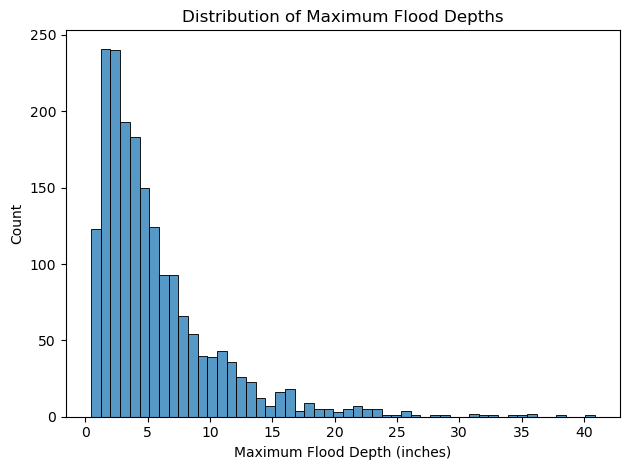

In [31]:
sns.histplot(merged_df['max_depth_inches'])

plt.title('Distribution of Maximum Flood Depths')
plt.xlabel('Maximum Flood Depth (inches)')
plt.ylabel('Count')

plt.tight_layout()

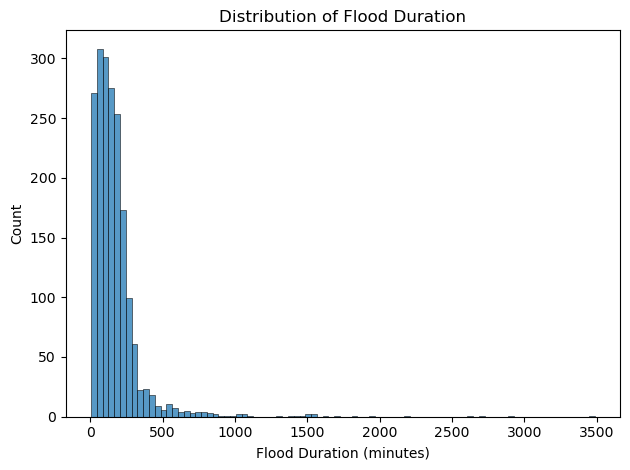

In [32]:
sns.histplot(merged_df['duration_mins'])

plt.title('Distribution of Flood Duration')
plt.xlabel('Flood Duration (minutes)')
plt.ylabel('Count')

plt.tight_layout()

# Example Visualization
## Flood Sensor Locations with Recorded Flooding
Recalculate the geometry column for example purposes.

In [33]:
# generate geometry from x, y points
geometry = gpd.points_from_xy(
    merged_df['longitude'].to_pandas(),
    merged_df['latitude'].to_pandas()
)

# create geodataframe
gdf = gpd.GeoDataFrame(
    merged_df.to_pandas(),
    geometry=geometry,
    crs=4326
)

# preview data
print(f'shape of data: {gdf.shape}')
print(gdf.crs)

gdf['geometry'].head()

shape of data: (1887, 30)
EPSG:4326


0    POINT (-73.80996 40.59136)
1    POINT (-73.88104 40.81285)
2    POINT (-73.76781 40.59662)
3    POINT (-73.90585 40.88326)
4    POINT (-73.83056 40.65339)
Name: geometry, dtype: geometry

/opt/miniconda3/envs/floodnet_env/lib/python3.11/site-packages/geopandas/plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


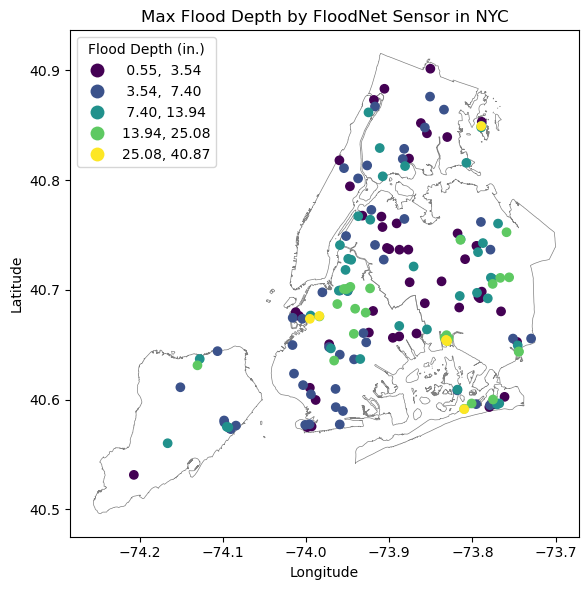

In [34]:
# create figure
fig, ax = plt.subplots(figsize=(6, 6))

# unique sensors by max flood depth
max_depth_gdf = (
    gdf.sort_values(
        by=['sensor_id', 'max_depth_inches'],
        ascending=[True, False]
    )
    .drop_duplicates(subset='sensor_name')
    # we sort again to plot the highest depths on top of neighboring points
    .sort_values(by='max_depth_inches', ascending=True)
)

# plot sensor locations with legend
max_depth_gdf.plot(
    column=max_depth_gdf['max_depth_inches'],
    scheme='FisherJenks',
    ax=ax,
    legend=True,
    legend_kwds={"title": "Flood Depth (in.)"},
)

# borough plot
boro_gdf.plot(
    ax=ax,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# aesthetics
plt.title("Max Flood Depth by FloodNet Sensor in NYC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# tight layout
plt.tight_layout()